# Compare P2 integer vs continuous solutions

Loads `P2_base.pkl` (integer/binary) and `P2_continuous.pkl` (relaxed LP) produced from `model_speed.py` (same long-form layout: `name`, `i`, `j`, `k`, `t`, `value`).

- **x**: site assignment, one entry per `i` ∈ {0,…,25}; `j,k,t` are placeholders (0).
- **y**: shape 26×26×6 in `(i, j, t)`; `k` is 0.
- **z**: full 26×26×26×6 in `(i, j, k, t)`.

Difference shown: `value_continuous − value_base`. For **y** and **z**, each panel is a 26×26 heatmap with **max over the remaining indices** of `|difference|` (so one scalar per `(i,j)`).

In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Run with working directory = folder that contains the .pkl files (e.g. light_version).
HERE = Path.cwd()
BASE_PKL = HERE / "P2_integer.pkl"
CONT_PKL = HERE / "P2_continuous.pkl"
if not BASE_PKL.is_file():
    raise FileNotFoundError(f"Expected {BASE_PKL} — change directory or set HERE.")

df_base = pd.read_pickle(BASE_PKL)
df_cont = pd.read_pickle(CONT_PKL)

df_base = df_base.rename(columns={"value": "value_base"})
df_cont = df_cont.rename(columns={"value": "value_cont"})

merged = df_base.merge(df_cont, on=["name", "i", "j", "k", "t"], how="inner")
merged["diff"] = merged["value_cont"] - merged["value_base"]

assert len(merged) == len(df_base) == len(df_cont), "Row counts should align on keys"
merged

,name,i,j,k,t,value_base,value_cont,diff
0,x,0,0,0,0,0.0,0,0.0
1,x,1,0,0,0,0.0,0,0.0
2,x,2,0,0,0,0.0,0,0.0
3,x,3,0,0,0,1.0,1,0.0
4,x,4,0,0,0,1.0,1,0.0
...,...,...,...,...,...,...,...,...
109533,z,25,25,25,1,0.0,0,0.0
109534,z,25,25,25,2,0.0,0,0.0
109535,z,25,25,25,3,0.0,0,0.0
109536,z,25,25,25,4,0.0,0,0.0


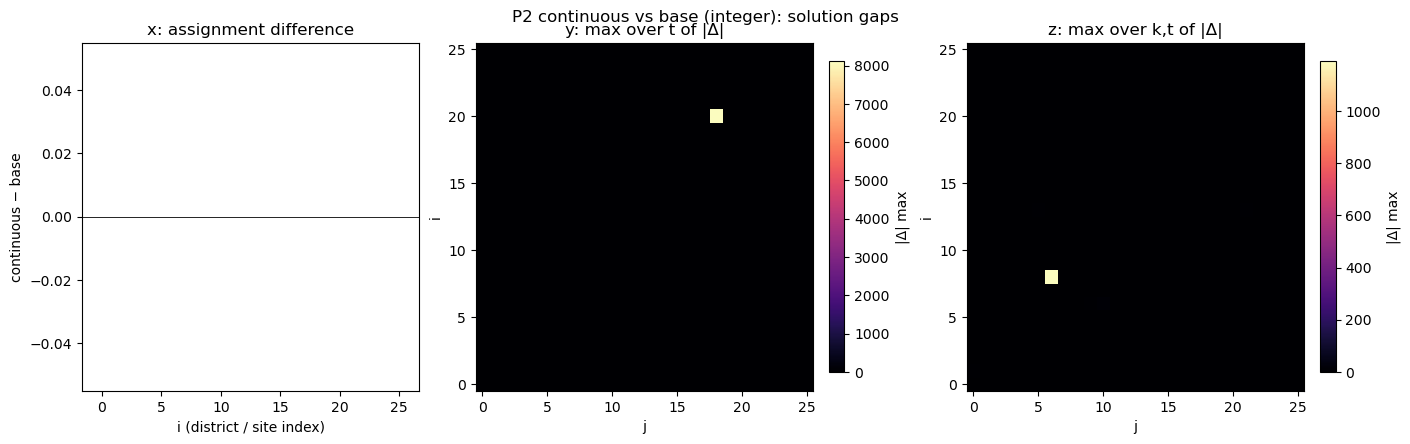

In [23]:
def heatmap_ij(df_name: str, merged_df: pd.DataFrame) -> np.ndarray:
    """Max over (k,t) for z, over t for y — only rows where name matches."""
    sub = merged_df[merged_df["name"] == df_name][["i", "j", "k", "t", "diff"]].copy()
    sub["abs_diff"] = sub["diff"].abs()
    # One value per (i,j): worst case over all other indices present in the slice
    g = sub.groupby(["i", "j"], as_index=False)["abs_diff"].max()
    n = 26
    mat = np.zeros((n, n), dtype=float)
    for _, r in g.iterrows():
        mat[int(r["i"]), int(r["j"])] = float(r["abs_diff"])
    return mat


dx = merged[merged["name"] == "x"].sort_values("i")
mat_y = heatmap_ij("y", merged)
mat_z = heatmap_ij("z", merged)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)

axes[0].bar(dx["i"], dx["diff"], color="steelblue", edgecolor="none")
axes[0].axhline(0, color="k", lw=0.6)
axes[0].set_xlabel("i (district / site index)")
axes[0].set_ylabel("continuous − base")
axes[0].set_title("x: assignment difference")
axes[0].set_xticks(range(0, 26, 5))

im1 = axes[1].imshow(mat_y, aspect="auto", origin="lower", cmap="magma")
axes[1].set_xlabel("j")
axes[1].set_ylabel("i")
axes[1].set_title("y: max over t of |Δ|")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="|Δ| max")

im2 = axes[2].imshow(mat_z, aspect="auto", origin="lower", cmap="magma")
axes[2].set_xlabel("j")
axes[2].set_ylabel("i")
axes[2].set_title("z: max over k,t of |Δ|")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label="|Δ| max")

fig.suptitle("P2 continuous vs base (integer): solution gaps", fontsize=12, y=1.02)
plt.show()

In [24]:
# Quick scalar summaries (optional)
for nm in ["x", "y", "z"]:
    d = merged.loc[merged["name"] == nm, "diff"]
    print(
        f"{nm}: max|Δ|={d.abs().max():.6g},  mean|Δ|={d.abs().mean():.6g},  rows={len(d)}"
    )

x: max|Δ|=0,  mean|Δ|=0,  rows=26
y: max|Δ|=8107,  mean|Δ|=4.0286,  rows=4056
z: max|Δ|=1190,  mean|Δ|=0.0239057,  rows=105456


In [25]:
merged[merged['diff']>10]


,name,i,j,k,t,value_base,value_cont,diff
3259,y,20,18,0,5,0.0,8105,8105.0
30038,z,6,10,10,0,1546.0,1557,11.0
37507,z,8,6,6,5,0.0,1189,1189.0


In [26]:
merged[merged['diff']<-10]

,name,i,j,k,t,value_base,value_cont,diff
3258,y,20,18,0,4,332926.0,324819,-8107.0
30039,z,6,10,10,1,3719.0,3707,-12.0
37506,z,8,6,6,4,1757.0,567,-1190.0


base: 2.595597359020e+08
cont: 2.595595218084e+08






In [29]:
((2.595597359020e+08-2.595595218084e+08)/2.595597359020e+08)*100

8.248336332324869e-05

In [27]:
sum(merged['value_base'])-sum(merged['value_cont'])

73.0